## 3DoF Entry GHAME w/o Aoa SCP

Imports

In [1]:
# Basic imports
import importlib
import numpy as np
import matplotlib.pyplot as plt

# Trajopt imports
import trajopt; importlib.reload(trajopt)
import trajopt.core.modules.method.scp as scp
import trajopt.core.problem as prob
import trajopt.utils.config_loader as cfg

create problem and run SCP

In [2]:
# create problem instance
config  = cfg.load_configs("ghame_entry_3dof")
problem = prob.Problem(config)

# run SCP
problem = scp.run_scp(problem)

scales: 
d: 6378137.0000, t: 806.3293, m: 54431.0000, v: 7910.0900, a: 9.8100, f: 533968.1100, ang: 57.2958, angv: 0.0711
--------------------------------------------------------------------------------------------------------------------------------------------------------
                                              ..:: ghame: PTR with Virtual Buffer ::..
--------------------------------------------------------------------------------------------------------------------------------------------------------
  Iteration |  Propagation |   Solve   |    Parse   |  log(dz)  |      log(VB)    |   log(VB)   |  log(VB)    | Solve status |  Time of    |   Cost    
            |   time [ms]  | time [ms] |  time [ms] |           |  (path + NFZ)   |  (terminal) |  (dynamics) |              |  Flight [s] |           
--------------------------------------------------------------------------------------------------------------------------------------------------------


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxpy/reductions/solvers/solving_chain_utils.py:41: UserWarning: The problem has an expression with dimension greater than 2. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


     01     |    00989.9   |   0009.9  |   3135.8   |   -4.5    |      -10.8      |    -03.4    |     -12.0   |    optimal    |   1979.77   |  -2.0
     02     |    00015.7   |   0008.9  |   0000.7   |   -3.8    |      -10.8      |    -03.5    |     -12.0   |    optimal    |   1978.27   |  -4.0
     03     |    00013.4   |   0009.1  |   0000.6   |   -3.7    |      -10.8      |    -03.6    |     -12.0   |    optimal    |   1978.84   |  -5.7
     04     |    00013.5   |   0008.9  |   0000.8   |   -3.7    |      -10.5      |    -03.8    |     -12.0   |    optimal    |   1981.43   |  -7.3
     05     |    00013.1   |   0009.8  |   0000.7   |   -3.7    |      -11.3      |    -04.0    |     -12.0   |    optimal    |   1984.27   |  -8.6
     06     |    00016.8   |   0009.4  |   0000.9   |   -3.9    |      -10.5      |    -04.4    |     -12.0   |    optimal    |   1985.26   |  -9.7
     07     |    00013.5   |   0010.4  |   0000.8   |   -3.9    |      -11.7      |    -12.0    |     -12.0   | 

run SCP

make plots

final time: 1986.7989012778683


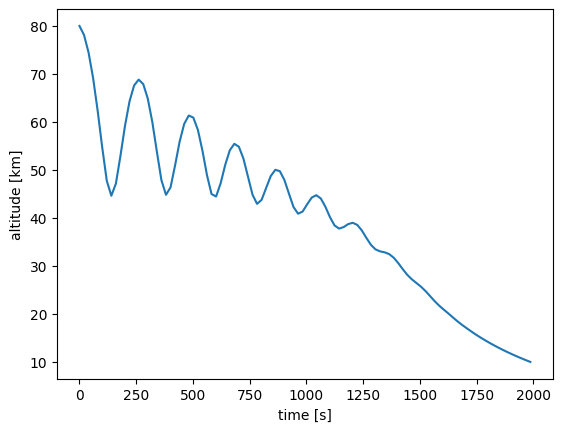

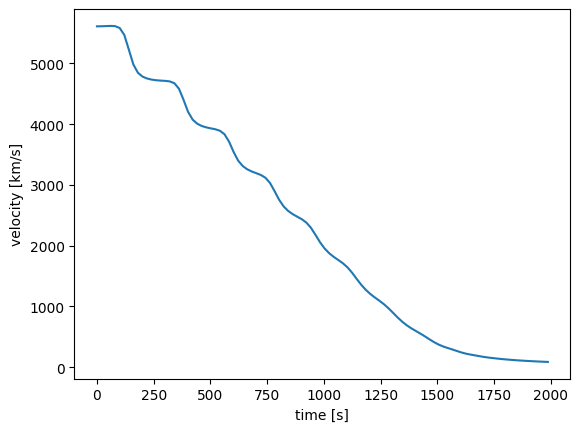

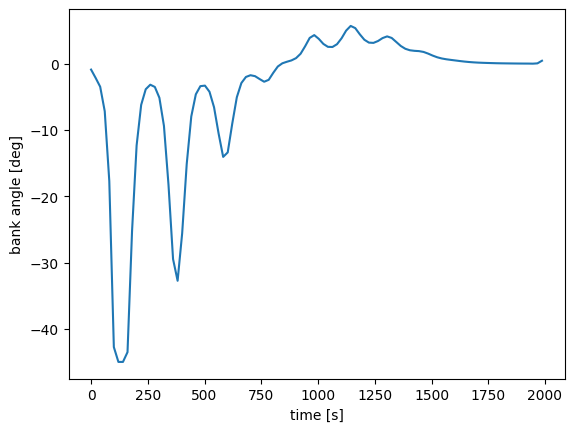

In [3]:
# --- 3D Interactivity (run %matplotlib widget in Jupyter) ---
#%matplotlib widget # ← run this once per notebook session

mission = problem.mission
model   = problem.model
method  = problem.method

# --- Retrieve trajectory and parameters ---

t_init = method.t_init
z_init = method.z_init
nu_init = method.nu_init
x_init  = z_init[:, 0]
y_init  = z_init[:, 1]
z_init  = z_init[:, 2]

t_opt  = problem.solution["ts"]
z_opt  = problem.solution["zs"]
nu_opt  = problem.solution["us"]

plt.plot(t_opt * method.nondim['nt'], (z_opt[:, 0] * method.nondim['nd'] - mission.planet['r']) / 1e3)
plt.ylabel('altitude [km]')
plt.xlabel('time [s]')

plt.figure()
plt.plot(t_opt*method.nondim['nt'], (z_opt[:, 3] * method.nondim['nv']))
plt.ylabel('velocity [km/s]')
plt.xlabel('time [s]')

plt.figure()
plt.plot(t_opt*method.nondim['nt'], np.rad2deg(nu_opt[:, 0]))
plt.ylabel('bank angle [deg]')
plt.xlabel('time [s]')

print(f"final time: {t_opt[-1] * method.nondim['nt']}")